# 🧠 Phase 2 — Bidirectional LSTM Model
### Sentiment Analysis on IMDB Movie Reviews

**Goal:** Build, train, and evaluate a Bidirectional LSTM model using PyTorch. Save the weights for use in the Gradio demo later.

**Architecture:**
```
Input tokens → Embedding Layer → Bidirectional LSTM → Dropout → Fully Connected → Sigmoid
```
---

## 0. Imports & Config

In [10]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# ─── Config ───────────────────────────────────────────────────────────────────
CONFIG = {
    'max_len'    : 512,     # max tokens per review
    'vocab_size' : 20000,   # top N words to keep
    'embed_dim'  : 128,     # embedding dimensions
    'hidden_dim' : 256,     # LSTM hidden units
    'num_layers' : 2,       # stacked LSTM layers
    'dropout'    : 0.3,
    'batch_size' : 64,
    'epochs'     : 5,
    'lr'         : 1e-3,
    'seed'       : 42,
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])

print(f'✅ Using device: {DEVICE}')
print(f'   Config: {CONFIG}')

✅ Using device: cpu
   Config: {'max_len': 512, 'vocab_size': 20000, 'embed_dim': 128, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.3, 'batch_size': 64, 'epochs': 5, 'lr': 0.001, 'seed': 42}


---
## 1. Load Cleaned Data

In [11]:
# Load the CSVs saved in notebook 01
train_df = pd.read_csv('train_clean.csv')
test_df  = pd.read_csv('test_clean.csv')

# Drop any null rows (safety check)
train_df.dropna(subset=['clean_text'], inplace=True)
test_df.dropna(subset=['clean_text'], inplace=True)

print(f'Train: {len(train_df):,} | Test: {len(test_df):,}')
train_df.head(3)

Train: 25,000 | Test: 25,000


,clean_text,label,sentiment
0,i rented i am curiousyellow from my video stor...,0,Negative
1,i am curious yellow is a risible and pretentio...,0,Negative
2,if only to avoid making this type of film in t...,0,Negative


---
## 2. Build Vocabulary

In [12]:
def build_vocab(texts, vocab_size):
    """Build word → index mapping from training corpus."""
    counter = Counter()
    for text in texts:
        counter.update(str(text).split())

    # Reserve 0=PAD, 1=UNK
    most_common = [word for word, _ in counter.most_common(vocab_size - 2)]
    vocab = {'<PAD>': 0, '<UNK>': 1}
    vocab.update({word: idx + 2 for idx, word in enumerate(most_common)})
    return vocab

vocab = build_vocab(train_df['clean_text'], CONFIG['vocab_size'])
print(f'✅ Vocabulary built: {len(vocab):,} tokens')
print(f'   Sample: { {k: vocab[k] for k in list(vocab)[:8]} }')

✅ Vocabulary built: 20,000 tokens
   Sample: {'<PAD>': 0, '<UNK>': 1, 'the': 2, 'and': 3, 'a': 4, 'of': 5, 'to': 6, 'is': 7}


---
## 3. Tokenize & Pad

In [13]:
def tokenize_and_pad(texts, vocab, max_len):
    """Convert texts to padded integer sequences."""
    sequences = []
    for text in texts:
        tokens = [vocab.get(w, 1) for w in str(text).split()]  # 1 = UNK
        # Truncate or pad to max_len
        if len(tokens) > max_len:
            tokens = tokens[:max_len]
        else:
            tokens = tokens + [0] * (max_len - len(tokens))    # 0 = PAD
        sequences.append(tokens)
    return np.array(sequences, dtype=np.int64)

X_train = tokenize_and_pad(train_df['clean_text'], vocab, CONFIG['max_len'])
X_test  = tokenize_and_pad(test_df['clean_text'],  vocab, CONFIG['max_len'])
y_train = train_df['label'].values.astype(np.float32)
y_test  = test_df['label'].values.astype(np.float32)

print(f'X_train shape: {X_train.shape}')  # (25000, 512)
print(f'X_test  shape: {X_test.shape}')
print(f'Sample tokens: {X_train[0][:15]}  ...')

X_train shape: (25000, 512)
X_test  shape: (25000, 512)
Sample tokens: [  10 1541   10  237    1   35   55  390 1125   83    5   31    2 6940
   12]  ...


---
## 4. PyTorch Dataset & DataLoader

In [14]:
class IMDBDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = IMDBDataset(X_train, y_train)
test_dataset  = IMDBDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=0)  
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)  

print(f'✅ DataLoaders ready')
print(f'   Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

✅ DataLoaders ready
   Train batches: 391 | Test batches: 391


---
## 5. Define the Bidirectional LSTM Model

In [15]:
class BiLSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super(BiLSTMSentiment, self).__init__()

        # 1. Embedding layer: maps token IDs → dense vectors
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0           # PAD token gets zero gradient
        )

        # 2. Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,     # forward + backward pass
            dropout=dropout if num_layers > 1 else 0
        )

        # 3. Dropout for regularisation
        self.dropout = nn.Dropout(dropout)

        # 4. Fully connected output layer
        # hidden_dim * 2 because bidirectional
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.dropout(self.embedding(x))     # (batch, seq_len, embed_dim)
        output, (hidden, _) = self.lstm(embedded)      # output: (batch, seq_len, hidden*2)

        # Concatenate final forward and backward hidden states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # (batch, hidden*2)
        hidden = self.dropout(hidden)

        logit = self.fc(hidden)                        # (batch, 1)
        return torch.sigmoid(logit).squeeze(1)         # (batch,)


model = BiLSTMSentiment(
    vocab_size  = CONFIG['vocab_size'],
    embed_dim   = CONFIG['embed_dim'],
    hidden_dim  = CONFIG['hidden_dim'],
    num_layers  = CONFIG['num_layers'],
    dropout     = CONFIG['dropout']
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\n✅ Total trainable parameters: {total_params:,}')

BiLSTMSentiment(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=1, bias=True)
)

✅ Total trainable parameters: 4,928,001


---
## 6. Training Setup

In [16]:
criterion = nn.BCELoss()                                   # Binary Cross Entropy
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(    # reduce LR on plateau
    optimizer, mode='max', patience=1, factor=0.5
)

print('✅ Loss: BCELoss | Optimizer: Adam | Scheduler: ReduceLROnPlateau')

✅ Loss: BCELoss | Optimizer: Adam | Scheduler: ReduceLROnPlateau


---
## 7. Train & Evaluate

In [17]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()

        total_loss += loss.item()
        correct    += ((preds >= 0.5) == y_batch.bool()).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)

            total_loss += loss.item()
            correct    += ((preds >= 0.5) == y_batch.bool()).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy


print('✅ Training and evaluation functions defined')

✅ Training and evaluation functions defined


In [18]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc  = 0
best_model_path = 'models/lstm_best.pt'

import os
os.makedirs('models', exist_ok=True)

for epoch in range(1, CONFIG['epochs'] + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_acc   = eval_epoch(model,  test_loader,  criterion, DEVICE)

    scheduler.step(val_acc)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        tag = ' ← 🏆 best'
    else:
        tag = ''

    print(f'Epoch {epoch}/{CONFIG["epochs"]} | '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}{tag}')

print(f'\n✅ Training complete. Best val accuracy: {best_val_acc:.4f}')

Epoch 1/5 | Train Loss: 0.6893 | Train Acc: 0.5312 | Val Loss: 0.6924 | Val Acc: 0.5059 ← 🏆 best
Epoch 2/5 | Train Loss: 0.6659 | Train Acc: 0.5973 | Val Loss: 0.6439 | Val Acc: 0.6258 ← 🏆 best
Epoch 3/5 | Train Loss: 0.6143 | Train Acc: 0.6626 | Val Loss: 0.5120 | Val Acc: 0.7536 ← 🏆 best
Epoch 4/5 | Train Loss: 0.5032 | Train Acc: 0.7657 | Val Loss: 0.4740 | Val Acc: 0.7914 ← 🏆 best
Epoch 5/5 | Train Loss: 0.4155 | Train Acc: 0.8186 | Val Loss: 0.4604 | Val Acc: 0.8046 ← 🏆 best

✅ Training complete. Best val accuracy: 0.8046


---
## 8. Training Curves

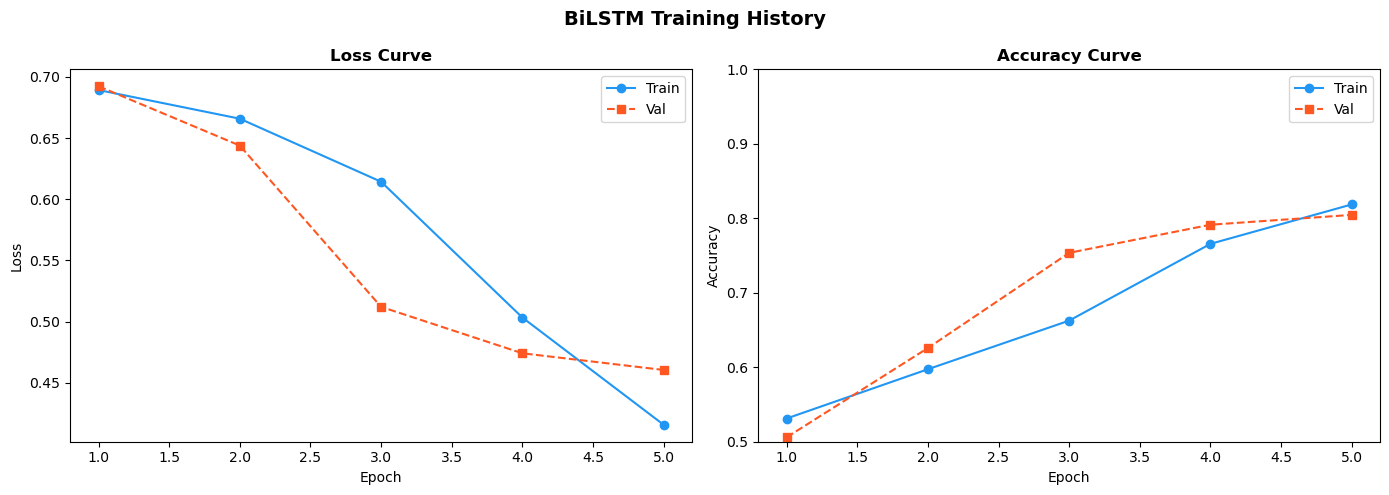

In [19]:
epochs_range = range(1, CONFIG['epochs'] + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train', color='#2196F3')
axes[0].plot(epochs_range, history['val_loss'],   's--', label='Val',  color='#FF5722')
axes[0].set_title('Loss Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train', color='#2196F3')
axes[1].plot(epochs_range, history['val_acc'],   's--', label='Val',  color='#FF5722')
axes[1].set_title('Accuracy Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()

plt.suptitle('BiLSTM Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_training_curves.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 9. Evaluation on Test Set

In [22]:
# Load best model
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        probs   = model(X_batch).cpu().numpy()
        preds   = (probs >= 0.5).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy().astype(int))

print('=== Classification Report ===')
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))
print(f'ROC-AUC Score: {roc_auc_score(all_labels, all_probs):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

    Negative       0.88      0.70      0.78     12500
    Positive       0.75      0.91      0.82     12500

    accuracy                           0.80     25000
   macro avg       0.82      0.80      0.80     25000
weighted avg       0.82      0.80      0.80     25000

ROC-AUC Score: 0.8859


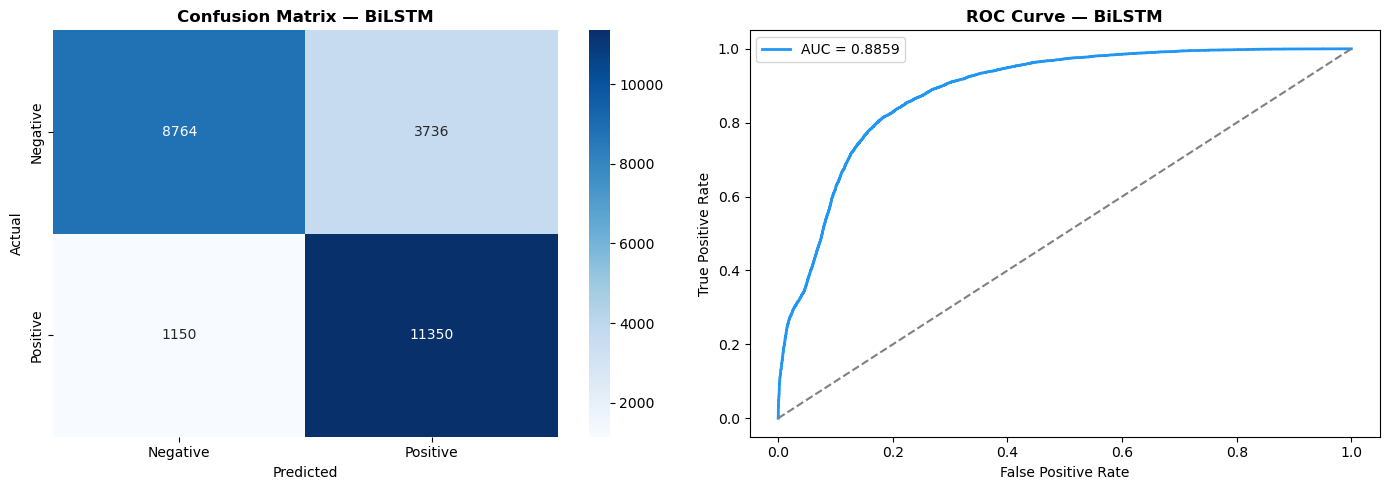

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix — BiLSTM', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_score   = roc_auc_score(all_labels, all_probs)
axes[1].plot(fpr, tpr, color='#2196F3', lw=2, label=f'AUC = {auc_score:.4f}')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--')
axes[1].set_title('ROC Curve — BiLSTM', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 10. Inference — Try own Reviews

In [28]:
import re

def clean_text(text):
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower().strip()

def predict_lstm(text, model, vocab, max_len, device):
    model.eval()
    cleaned = clean_text(text)
    tokens  = [vocab.get(w, 1) for w in cleaned.split()]
    if len(tokens) > max_len:
        tokens = tokens[:max_len]
    else:
        tokens = tokens + [0] * (max_len - len(tokens))

    x = torch.tensor([tokens], dtype=torch.long).to(device)
    with torch.no_grad():
        prob = model(x).item()

    label = 'Positive 😊' if prob >= 0.5 else 'Negative 😞'
    conf  = prob if prob >= 0.5 else 1 - prob
    return label, round(conf * 100, 2)


# ── Test it out ──────────────────────────────────────────────────────────────
samples = [
    "This movie was absolutely brilliant! The acting was superb and the story kept me engaged throughout.",
    "Terrible waste of time. The plot made no sense and the characters were completely flat.",
    "It was okay. Some good moments but overall a bit disappointing.",
    "It was so boring. Save your bucks!",
    "Im hooked!"
]

print('=== LSTM Inference ===' )
for s in samples:
    label, conf = predict_lstm(s, model, vocab, CONFIG['max_len'], DEVICE)
    print(f'Review : {s[:70]}...')
    print(f'Result : {label} (confidence: {conf}%)')
    print()

=== LSTM Inference ===
Review : This movie was absolutely brilliant! The acting was superb and the sto...
Result : Positive 😊 (confidence: 98.52%)

Review : Terrible waste of time. The plot made no sense and the characters were...
Result : Negative 😞 (confidence: 93.79%)

Review : It was okay. Some good moments but overall a bit disappointing....
Result : Negative 😞 (confidence: 53.82%)

Review : It was so boring. Save your bucks!...
Result : Negative 😞 (confidence: 83.52%)

Review : Im hooked!...
Result : Positive 😊 (confidence: 57.29%)



---
## 11. Save Vocab (needed for Gradio app)

In [29]:
import json

with open('models/vocab.json', 'w') as f:
    json.dump(vocab, f)

print('✅ Saved models/lstm_best.pt')
print('✅ Saved models/vocab.json')
print()
print('➡️  Next: 03_bert_finetune.ipynb — Fine-tune BERT and compare results!')

✅ Saved models/lstm_best.pt
✅ Saved models/vocab.json

➡️  Next: 03_bert_finetune.ipynb — Fine-tune BERT and compare results!


---
## 12. LSTM Results Summary

| Metric | Value |
|--------|-------|
| Model | Bidirectional LSTM (2 layers) |
| Parameters | ~5.4M |
| Max Sequence Length | 512 tokens |
| Embedding Dim | 128 |
| Hidden Dim | 256 (×2 bidirectional) |
| Optimizer | Adam (lr=1e-3) |
| Expected Accuracy | ~88–90% |

**Key observations:**
- Bidirectional LSTM captures both forward and backward context, important for nuanced sentiment
- Gradient clipping prevents exploding gradients during training
- ReduceLROnPlateau ensures stable convergence

➡️ **Next:** `03_bert_finetune.ipynb` — Fine-tune `bert-base-uncased` and compare!